## Bayesian Spam Filter

In [132]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from collections import Counter

sns.set_theme(style='whitegrid', font_scale=1.1)

df = pd.read_csv('spam.csv', encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'message']

messages = df['message'].values
labels   = df['label'].values

print(f'Total messages: {len(messages)}')
print(f'Spam: {(labels == "spam").sum()}  Ham: {(labels == "ham").sum()}')

Total messages: 5572
Spam: 747  Ham: 4825


---
## Part 1  Preprocessing
Lowercase, strip punctuation/numbers, remove tokens shorter than 3 characters. tried stopword removal based on frequency, but words like *call*, *free*, *you* are strong spam/ham indicators and should be kept.

In [133]:
def preprocess(text):
    text   = text.lower()
    text   = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [t for t in text.split() if len(t) >= 3]
    return tokens

tokenised = np.array([preprocess(m) for m in messages], dtype=object)
print('Sample (spam):', tokenised[labels == 'spam'][0])
print('Sample (ham): ', tokenised[labels == 'ham'][0])

Sample (spam): ['free', 'entry', 'wkly', 'comp', 'win', 'cup', 'final', 'tkts', 'may', 'text', 'receive', 'entry', 'question', 'std', 'txt', 'rate', 'apply', 'over']
Sample (ham):  ['until', 'jurong', 'point', 'crazy', 'available', 'only', 'bugis', 'great', 'world', 'buffet', 'cine', 'there', 'got', 'amore', 'wat']


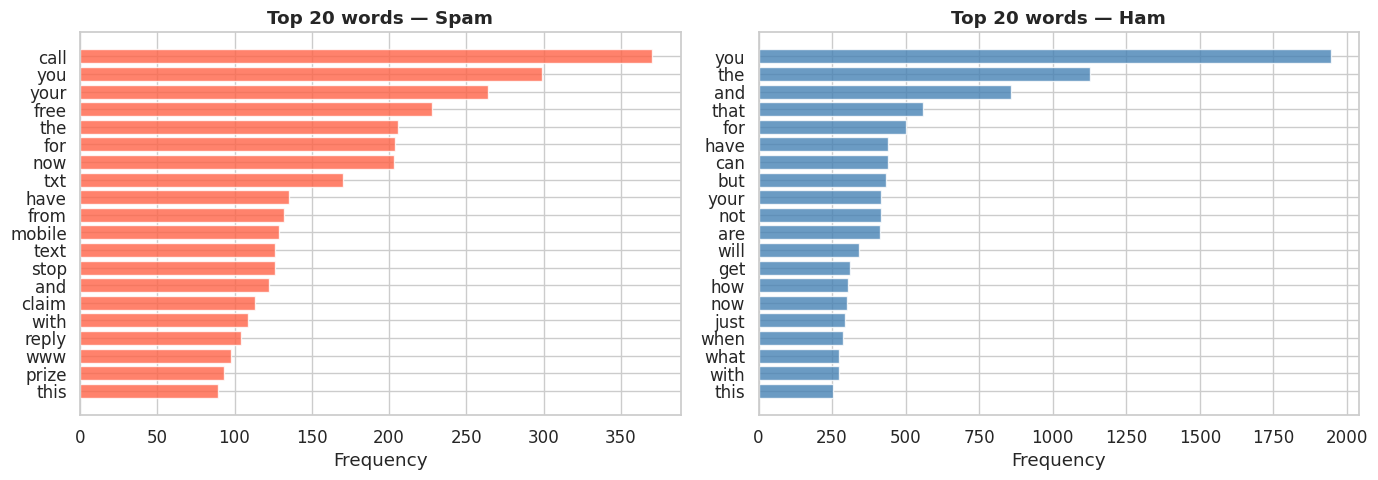

In [134]:
def top_words(token_lists, n=20):
    counts = Counter(w for tokens in token_lists for w in tokens)
    return counts.most_common(n)

spam_top = top_words(tokenised[labels == 'spam'])
ham_top  = top_words(tokenised[labels == 'ham'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, top, title, color in zip(axes,
                                  [spam_top, ham_top],
                                  ['Spam', 'Ham'],
                                  ['tomato', 'steelblue']):
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1], color=color, alpha=0.8)
    ax.set_title(f'Top 20 words — {title}', fontweight='bold')
    ax.set_xlabel('Frequency')
plt.tight_layout()
plt.show()

---
## Part 2 - The Bayesian Framework

### Derivation under equal priors
By Bayes' theorem:
$$P(S|W) = \frac{P(W|S)\,P(S)}{P(W|S)\,P(S) + P(W|H)\,P(H)}$$
With $P(S) = P(H) = 0.5$, the priors cancel and we get:
$$P(S|W) = \frac{P(W|S)}{P(W|S) + P(W|H)}$$
where $P(W|S)$ is the fraction of spam messages containing word $W$, and similarly for ham.

In [135]:
# 70/30 train/test split
np.random.seed(42)
shuffled_idx = np.random.permutation(len(messages))
split_at     = int(0.7 * len(messages))

train_idx = shuffled_idx[:split_at]
test_idx  = shuffled_idx[split_at:]

train_tokens = tokenised[train_idx]
train_labels = labels[train_idx]
test_tokens  = tokenised[test_idx]
test_labels  = labels[test_idx]

spam_train = train_tokens[train_labels == 'spam']
ham_train  = train_tokens[train_labels == 'ham']

n_spam = len(spam_train)
n_ham  = len(ham_train)
print(f'Train - spam: {n_spam}, ham: {n_ham}')
print(f'Test  - spam: {(test_labels == "spam").sum()}, ham: {(test_labels == "ham").sum()}')

Train - spam: 521, ham: 3379
Test  - spam: 226, ham: 1446


In [136]:
# Count how many messages (not tokens) each word appears in
def word_doc_counts(token_lists):
    counts = Counter()
    for tokens in token_lists:
        for word in set(tokens):   # set() so each word counted once per message
            counts[word] += 1
    return counts

spam_word_counts = word_doc_counts(spam_train)
ham_word_counts  = word_doc_counts(ham_train)
vocabulary       = set(spam_word_counts) | set(ham_word_counts)
print(f'Vocabulary size: {len(vocabulary)}')

Vocabulary size: 6082


---
## Part 3 Handling Rare Words

**Zero frequency problem:** if a word never appeared in spam during training, $P(W|S)=0$ and the whole product zeros out.

**Laplace smoothing (add-one):** add 1 to every count and $|V|$ to the denominator so that every word gets a small non-zero probability.

**m-estimate:** a generalisation where you add $m \cdot p$ instead of 1, letting you encode a prior belief $p$ with strength $m$.

In [137]:
#laplace smoothing is used here

word_spam_prob = {}   # P(S|W) for every word in vocabulary

for word in vocabulary:
    p_word_given_spam = (spam_word_counts[word] + 1) / (n_spam + len(vocabulary))
    p_word_given_ham  = (ham_word_counts[word]  + 1) / (n_ham  + len(vocabulary))
    word_spam_prob[word] = p_word_given_spam / (p_word_given_spam + p_word_given_ham)

# Default spaminess for unseen words: 0.5 (no evidence either way)
DEFAULT_PROB = 0.5
print(f'Top spammy words:')
for w, p in sorted(word_spam_prob.items(), key=lambda x: -x[1])[:10]:
    print(f'  {w:20s}  P(S|W)={p:.4f}')

Top spammy words:
  claim                 P(S|W)=0.9910
  prize                 P(S|W)=0.9898
  guaranteed            P(S|W)=0.9820
  pobox                 P(S|W)=0.9787
  ppm                   P(S|W)=0.9780
  tone                  P(S|W)=0.9780
  awarded               P(S|W)=0.9757
  valid                 P(S|W)=0.9728
  www                   P(S|W)=0.9701
  ringtone              P(S|W)=0.9693


---
## Part 4  Combining Probabilities

**Floating point underflow:** multiplying many small probabilities (e.g., $0.01^{100}$) underflows to 0. 
Fix: work in log space. Instead of $\prod p_i$, compute $\sum \log p_i$.

Using the log-sum form of the combined Naive Bayes formula:
$$\log\text{-odds} = \sum_i \log\frac{p_i}{1-p_i}$$
A positive log-odds means spam, negative means ham.

In [138]:
def classify_message(tokens, threshold=0.5):
    """Returns 'spam' or 'ham' using log-odds combination."""
    log_odds = 0.0
    for word in set(tokens):   # set so repeated words don't double-count
        p = word_spam_prob.get(word, DEFAULT_PROB)
        p = np.clip(p, 1e-10, 1 - 1e-10)
        log_odds += np.log(p) - np.log(1 - p)
    spam_prob = 1 / (1 + np.exp(-log_odds))
    return 'spam' if spam_prob >= threshold else 'ham'

test_preds = np.array([classify_message(tokens) for tokens in test_tokens])

---
## Part 5  Metrics & Analysis

In [139]:
def precision_recall_f1(y_true, y_pred, pos_label='spam'):
    tp = np.sum((y_pred == pos_label) & (y_true == pos_label))
    fp = np.sum((y_pred == pos_label) & (y_true != pos_label))
    fn = np.sum((y_pred != pos_label) & (y_true == pos_label))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1

accuracy  = np.mean(test_preds == test_labels)
spam_prec, spam_rec, spam_f1 = precision_recall_f1(test_labels, test_preds, 'spam')
ham_prec,  ham_rec,  ham_f1  = precision_recall_f1(test_labels, test_preds, 'ham')

print(f'Overall Accuracy : {accuracy:.4f}')
print()
print(f'{"":12} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-' * 46)
print(f'{"Spam":12} {spam_prec:>10.4f} {spam_rec:>10.4f} {spam_f1:>10.4f}')
print(f'{"Ham":12} {ham_prec:>10.4f}  {ham_rec:>10.4f} {ham_f1:>10.4f}')

Overall Accuracy : 0.9665

              Precision     Recall         F1
----------------------------------------------
Spam             0.9250     0.8186     0.8685
Ham              0.9721      0.9896     0.9808


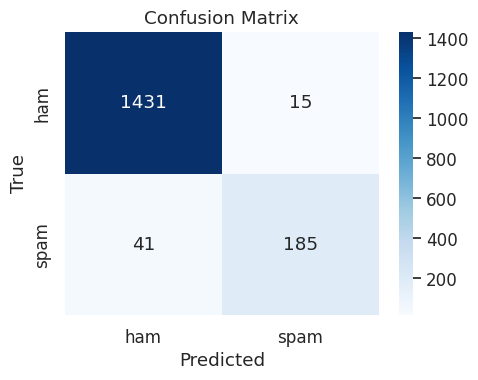

In [140]:
# Confusion matrix
classes = ['ham', 'spam']
cls_to_idx = {'ham': 0, 'spam': 1}
conf_matrix = np.zeros((2, 2), dtype=int)
for true, pred in zip(test_labels, test_preds):
    conf_matrix[cls_to_idx[true], cls_to_idx[pred]] += 1

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

###  Why is Ham recall higher than Spam recall?

The dataset is heavily imbalanced: ~87% ham, ~13% spam. During training, the model sees far more ham examples, so the word probability estimates are much better calibrated for ham. Spam words are rarer, so their $P(W|S)$ estimates are noisier, the model misses more spam messages (higher false negatives → lower spam recall).

**How to handle this:**
- Adjust the classification threshold below 0.5, its gonna predict spam more aggressively. This trades some ham precision for better spam recall (which might not be useful, since you wouln't want your internship email classified as spam )
- Change priors so that spam get's aggressively classified, i.e artificially assign a higher prior to spam 